In [2]:
#NOTEBOOK FOR ANALYSIS OF SARGASSUM SIMULATIONS FOR 12 START TIMES

import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d
import calculate_2DHistogram_method01 as c_H
import grid_initialization as gi
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from matplotlib import colormaps as mcolormaps

In [3]:
#Opening dataset of Lagrangian simulation based on satellite data release locations

DSS1 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM_westcar_LA_2023_04_01.zarr").dropna(dim='obs', how='all')

DSS2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM2_westcar_LA_2023_04_01.zarr").dropna(dim='obs', how='all')



#Starttime definitions
starttimesim = datetime(2023,4,1)


#Definition of time array
time_in_hours = ((DSS1['time']-DSS1['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSS1['time'] - DSS1['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

print('Size of DS1 file:' , DSS1.sizes)


Size of DS1 file: Frozen({'trajectory': 20043, 'obs': 360})


In [4]:
DSSs = [DSS2]

In [3]:
DSS1.sizes

Frozen({'trajectory': 93013, 'obs': 372})

In [10]:
#August data to check
imgaug1 = "/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
imgaug2 = "/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
imgaug3 = '/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png'
imgmay2023 = '/nethome/6903894/testing/Input_data_test/C20231152023121.1KM.GCOOS.7DAY.L3D.FA_UNET_DENSITY.png'

(2, 372)


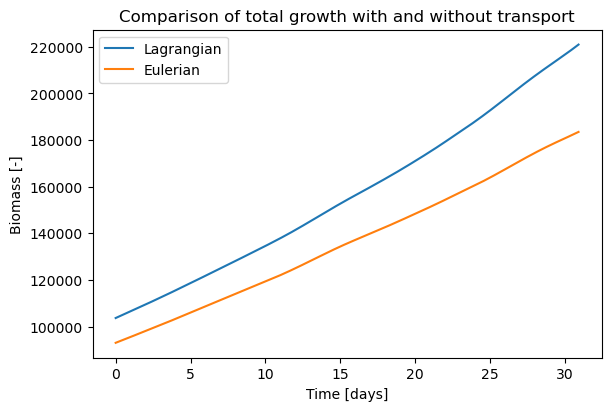

In [7]:

#Calculating the mean over time
weights = [L['biomass_SF3'][:,:].sum(dim='trajectory')   for L in both] 
weights = np.array(weights)
labels = ['Lagrangian', 'Eulerian']

#Definition of time array
time_in_hours = ((DSS1['time']-DSS1['time'][:,0]).astype("timedelta64[h]"))

time_in_days = ((DSS1['time'] - DSS1['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24


print(np.shape(weights))

weightplot = plt.figure(figsize=(6,4), constrained_layout=True)
for i in range(len(weights)):
    plt.plot(time_in_days[0,:], weights[i,:], label = labels[i])

plt.xlabel('Time [days]')
plt.ylabel('Biomass [-]')
plt.title('Comparison of total growth with and without transport')
plt.legend()
plt.show()

In [11]:
aug_lon_C, aug_lat_C, amount_aug_C = gi.sarg_grid_from_sat(imgaug1, 22.0, 0.0, -38.0, -63.0, coarse=True, as_pset=False)
aug_lon_CE, aug_lat_CE, amount_aug_CE = gi.sarg_grid_from_sat(imgaug2, 22.0, 0.0, -11.5, -38.0, coarse=True, as_pset=False)
aug_lon_E, aug_lat_E, amount_aug_E = gi.sarg_grid_from_sat(imgaug3, 23.0, 10.0, -60.0, -75.0, coarse=True, as_pset=False)

may_lon, may_lat, amount_may = gi.sarg_grid_from_sat(imgmay2023, 31.0, 18.0, -79.0, -98.0, coarse=True, as_pset=False)

Shape of particle set: (1210, 1375)
Shape of particle set: (1210, 1458)
Shape of particle set: (715, 825)
Shape of particle set: (715, 1045)


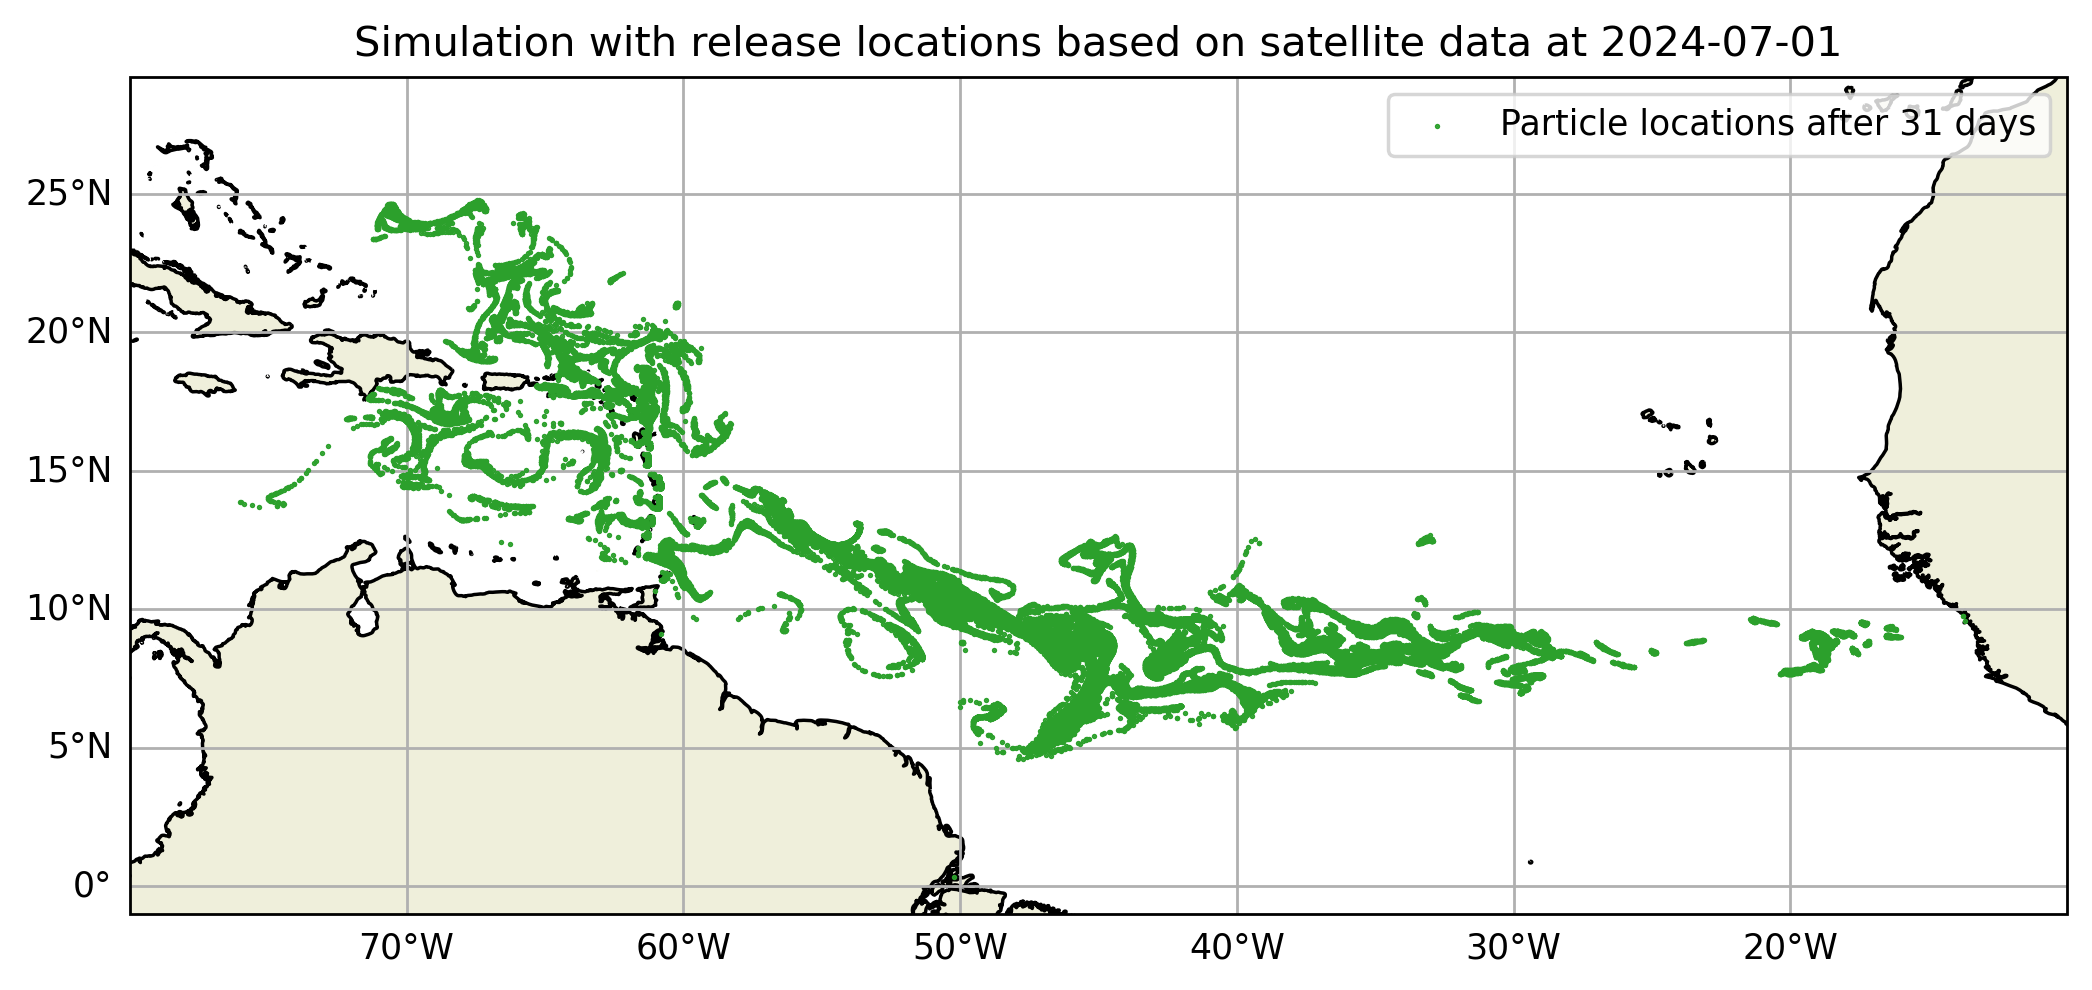

In [15]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import shapely

#pincar = DSL1.where(hi, drop=False)
#pincar

#Figure for plotting trajectories
fig2 = plt.figure(figsize = (10,6), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())

#End locations scatterplot
#eplot = ax.scatter(DSL1.lon[:,-1], DSL1.lat[:,-1], s = 0.5 ,color='tab:red', label= 'Jan transport') #Transposing lon and lat arrays!
#eplot = ax.scatter(DSS1.lon[:,0], DSS1.lat[:,0], s = 0.5 ,color='violet', label = 'Starting locations') #Transposing lon and lat arrays!


# satplot = ax.scatter(aug_lon_C, aug_lat_C, s = 0.3, c='b', label='Satellite detections at 01-08-2024',zorder=6)
# satplot2 = ax.scatter(aug_lon_CE, aug_lat_CE, s = 0.3, c='b', zorder=6)
# satplot3 = ax.scatter(aug_lon_E, aug_lat_E, s = 0.3, c='b', zorder=6)
eplot = ax.scatter(DSS1.lon[:,-1], DSS1.lat[:,-1], s = 0.3 ,color='tab:green', label = 'Particle locations after 31 days',zorder=7) #Transposing lon and lat arrays!
#eplot = ax.scatter(DSS2de.lon[:,-1], DSS2de.lat[:,-1], s = 0.3 ,color='tab:brown', label = 'Particle locations after 31 days, biomass dependence',zorder=7) #Transposing lon and lat arrays!
#eplot = ax.scatter(DSS1.lon[:,0], DSS1.lat[:,0], s = 0.3 ,color='tab:purple', label = 'Particle locations start',zorder=7) #Transposing lon and lat arrays!

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Simulation with release locations based on satellite data at {starttimejul.date()}')
ax.set_extent([-80,-10,-1,25])
ax.legend()
plt.show()

In [8]:
import shapely
import xarray as xr
import geopandas as gpd

caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")


def in_polygon_function(ds, poly):
    """Return a boolean DataArray marking points inside the polygon."""
    # Create shapely Point objects for all (lon, lat) pairs
    points = shapely.points(ds.lon, ds.lat)

    # Vectorized containment check (returns a boolean NumPy array)
    mask = shapely.contains(poly, points)

    # Wrap it back into an xarray DataArray with original coordinates
    return xr.DataArray(mask, coords=ds.coords)

hi = in_polygon_function(DSS1, caribbean_poly.geometry.iloc[0])
hi

<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

Length:  20043
Frozen({'trajectory': 20043, 'obs': 360})
360
Frozen({'trajectory': 17460, 'obs': 360})
360
(2, 360) (2, 360)
0.027807625089002523
360
360


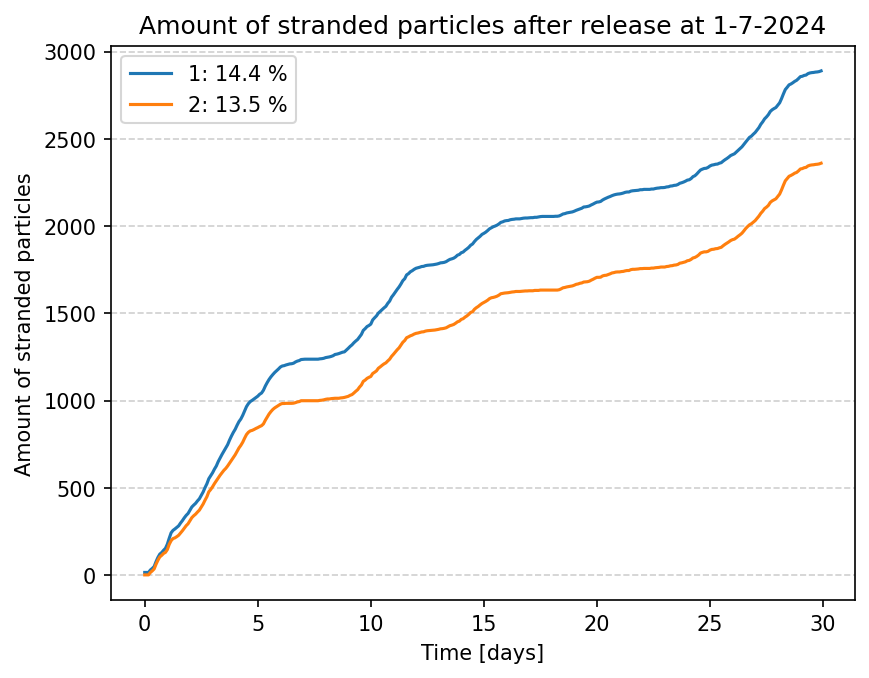

In [15]:
#print(len(DSAAN.trajectory)) ?????????????????????????????????????????????????????????

DSSs = [DSS1, DSS2]
labels = ['1', '2']

strand = []
strand_percentage = []
print('Length: ', len(DSS1.trajectory))
for ds in DSSs:
    # sum stranded particles along the obs dimension (axis=0)
    print(ds.sizes)
    print(len(ds.obs))
    until = len(ds.obs)
    stranded_sum = np.sum(ds.stranded[:,:
    ], axis=0)
    strand.append(stranded_sum)
    stranded_percentage = 100 * stranded_sum / len(ds.trajectory)
    strand_percentage.append(stranded_percentage)

# Convert to a numpy array if needed
strand = np.array(strand)
strand_percentage=np.array(strand_percentage)
print(strand.shape, strand_percentage.shape)
#print(strand_percentage[:,-1])
print(2148/77245)
fig = plt.figure(dpi=150)
for i in range(len(DSSs)):
    until = len(DSSs[i].obs)
    print(until)
    plt.plot(time_in_days[0,:until], strand[i,:until], label = f'{labels[i]}: {strand_percentage[i,-1]:.1f} %')
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend()
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

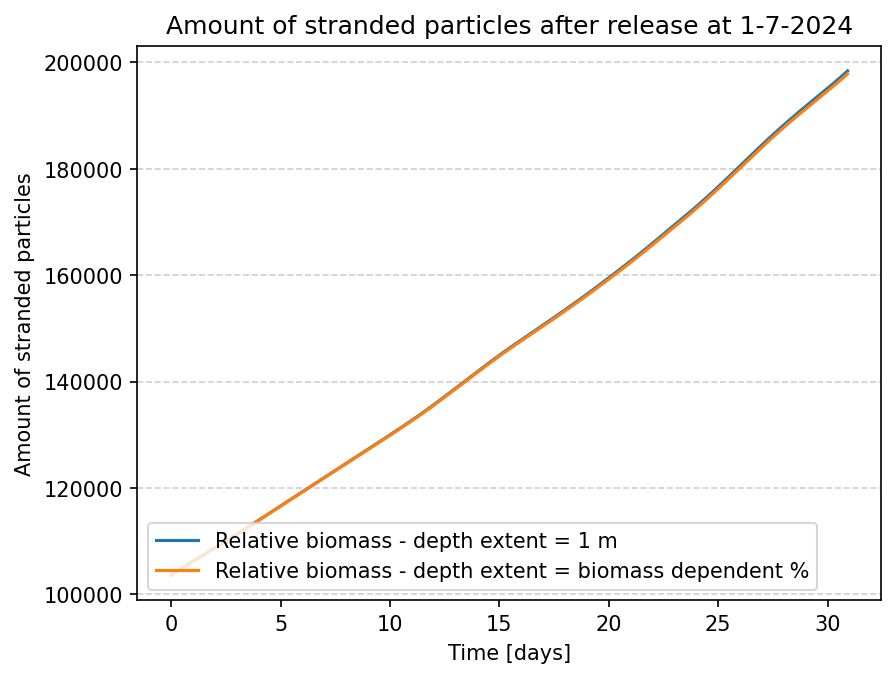

In [24]:
fig = plt.figure(dpi=150)

biomass = [E['biomass_SF3'].sum(dim='trajectory')     for E in DSSs]  

biomass = np.array(biomass)

#biomass_loss = [E['biomass_loss'].sum(dim='trajectory')     for E in DSSs]  
#biomass_loss = np.array(biomass_loss)
plt.plot(time_in_days[0,:], biomass[0,:].T, label = f'Relative biomass - depth extent = 1 m')
plt.plot(time_in_days[0,:], biomass[1,:].T, label = f'Relative biomass - depth extent = biomass dependent %')
#plt.plot(time_in_days[0,:], biomass_loss.T, label = f'Loss  %')
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend(loc='lower left')
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

[-97.20914979 -97.20897834 -97.20892338 ... -78.34995181 -78.34605548
 -78.34621808]
0


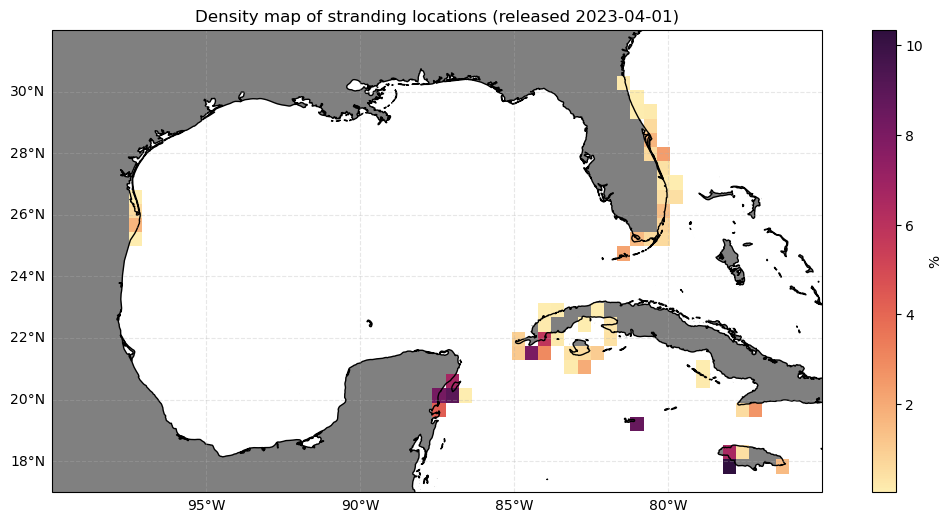

In [ ]:
bins_x = 50
bins_y = 28

DSS1_lasttimestep = DSS2.isel(obs=-1)
stranded =  DSS1_lasttimestep.where(DSS1_lasttimestep['stranded'].compute()==1, drop=True)    #for X in DSLs] 

print(stranded.lon.values)
print(np.isnan(stranded.lon.values).sum())  # should be 0 ideally

probability_stranding = c_H.probability_density(stranded, bins_x, bins_y)
probability_last = c_H.probability_density(DSS1_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-100, -75]
ylim= [17, 32]

stranded
#plot the results
c_H.probability_map(probability_stranding, xlim, ylim, f'Density map of stranding locations (released {starttimesim.date()})', None)

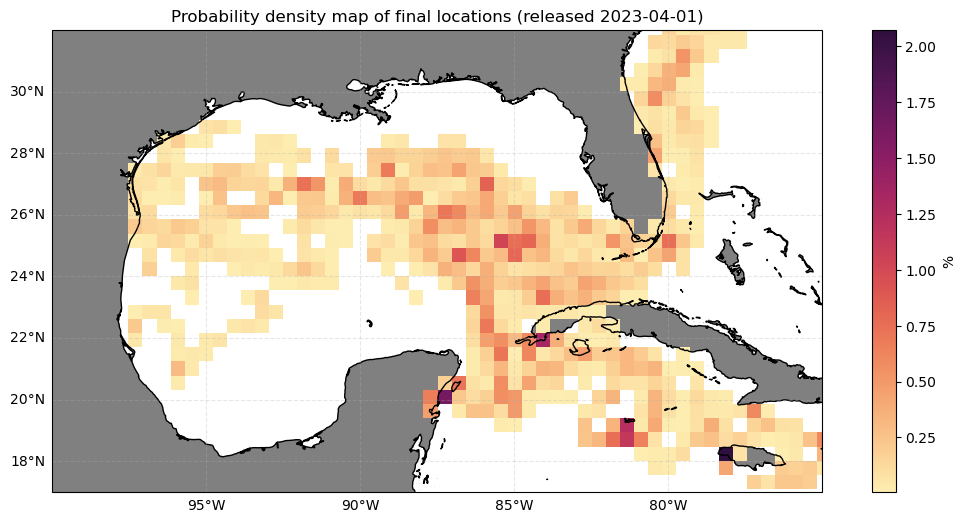

In [18]:
c_H.probability_map(probability_last, xlim, ylim, f'Probability density map of final locations (released {starttimesim.date()})', None)

In [4]:
def categorized_biomass_plot(DATA,  DIV, COLORMAP, STARTTIME, FINAL=True):
    #Categorizing based on weight and multiplying by category step size #SO THIS VALUE IS THE UPPER BOUNDARY OF THE BIN THAT THE PARTICLE WEIGHT IS CLASSIFIED IN!!!!
    categorized_id = np.digitize(DATA.biomass_SF3, DIV, right=False) #get bin indices for each weight (np.digitize gives the bin index of each weight)
    categorized_upper = DIV[categorized_id]
    categorized_lower = DIV[categorized_id - 1]
    DATA["biomass_SF3_categorized"] = (DATA.biomass_SF3.dims, categorized_lower) #Stores lower boundary of category that particle weight is in in dataset

    #Settings for the colormap and colorbar
    number_of_bins = len(DIV)
    boundaries = DIV
    # #colormap = plt.cm.get_cmap('plasma', number_of_bins )
    #colormap = plt.cm.get_cmap('YlGnBu', number_of_bins )
    #norm = mcolors.BoundaryNorm(boundaries[:], number_of_bins)
    colormap = COLORMAP
    norm = mcolors.BoundaryNorm(boundaries[:], ncolors=colormap.N, clip=False)

    #FIGURE
    fig = plt.figure(figsize = (10,7), dpi=250)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

    if FINAL == True:
        cscat = ax.scatter(DATA.lon[:,-1], DATA.lat[:,-1], c = DATA.biomass_SF3_categorized[:,-1].values,
        cmap=colormap, norm=norm, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)
    else:
    #Colored scatter plot with STARTING lon, lat and FINAL values of the categorized weight
        cscat = ax.scatter(DATA.lon[:,0], DATA.lat[:,0], c = DATA.biomass_SF3_categorized[:,-1].values,
        cmap=colormap, norm=norm, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)

    #Plotting of stranded particles settings
    # if DATA['stranded'].any() == 1:
    #     print('there are stranded particles')
    #     mask = (DSL1['stranded']==1).compute()
    #     stranded_slice = DSL1.where(mask, drop=True)
    #     ax.scatter(stranded_slice.lon, stranded_slice.lat, c='tab:green', s=0.5)
    # else:
    #     print('no stranded particles')

    #Other figure settings
    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'),zorder=3)
    if FINAL == True:
        ax.set_title(f'Relative biomass after 31 days (released {STARTTIME.date()})')
    else:
        ax.set_title(f'Relative biomass after 31 days for initial location (released {STARTTIME.date()})')
    #ax.set_extent([-78,-15,-4,19])
    #ax.set_extent([-75,-18,-3,17])
    #ax.set_extent([-59,-50,3,12])
    cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Relative biomass category', shrink=0.5)
    return plt.show()

#categorized_weight_plot(DSL3, div, cmo.algae, starttimejan, FINAL=False)

MAX:  3.8132164  MIN:  0.585163


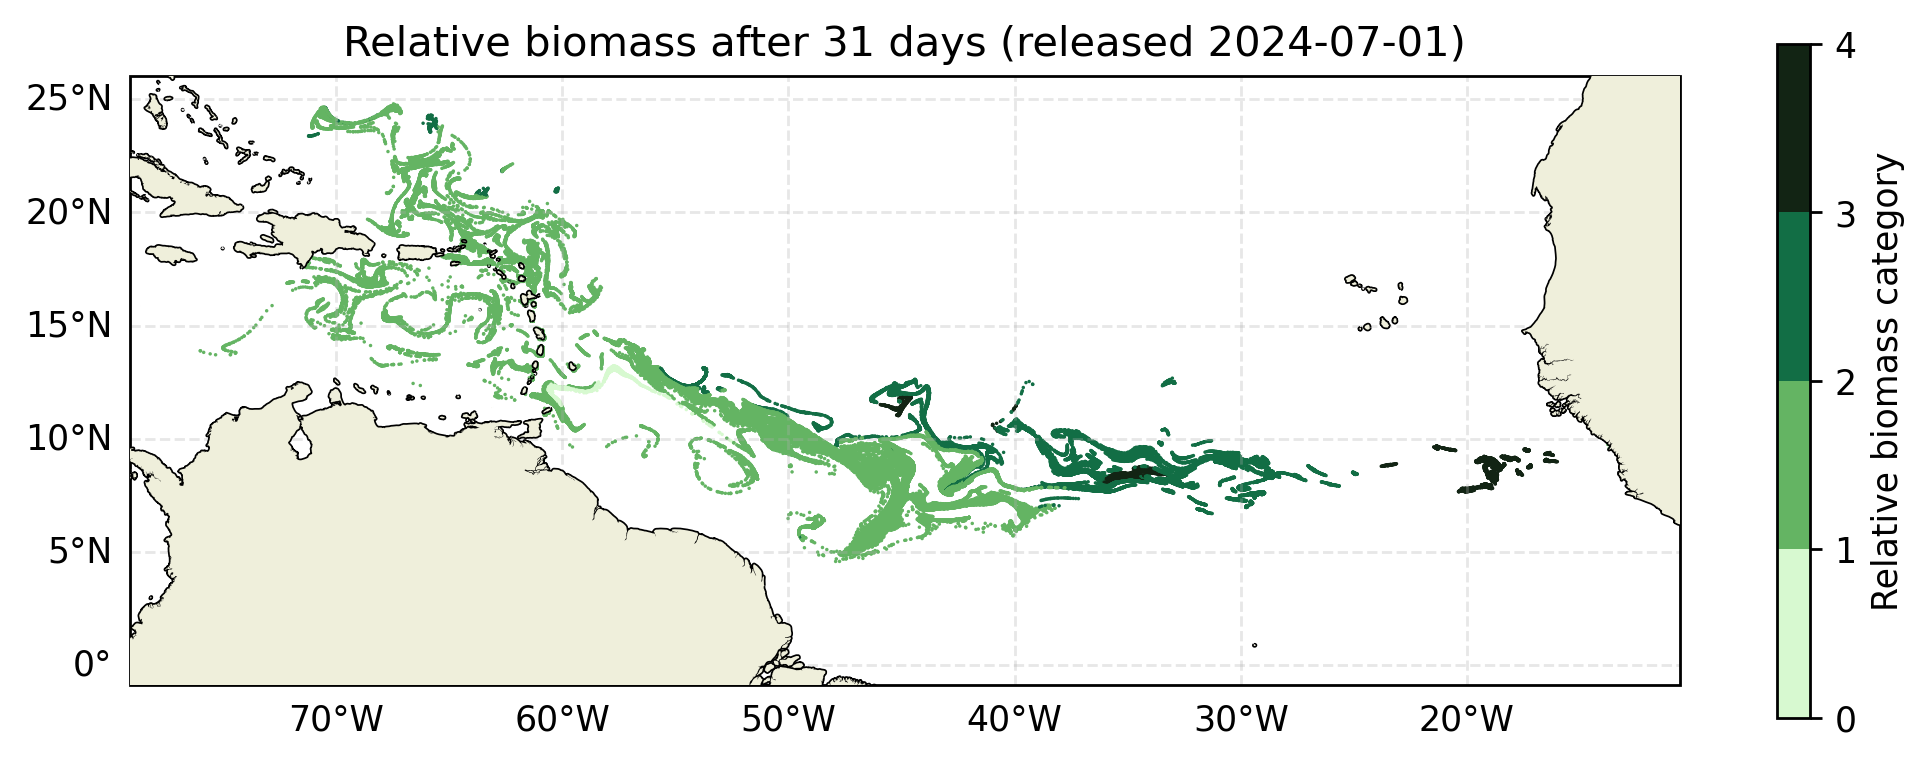

In [27]:
#Evaluating the min and max to be able to define the right categories #DEZE PLOT DUS ALS EEN FUNCTIE!!!!
max_SF3 = np.nanmax(DSS1.biomass_SF3)
min_SF3 = np.nanmin(DSS1.biomass_SF3)
print('MAX: ', max_SF3, ' MIN: ',min_SF3)

div = np.linspace(0, 4, 5)   #creating 9 equally spaced bin edges between 0 and 400
categorized_biomass_plot(DSS1, div, cmo.algae, starttimejul, FINAL=True)

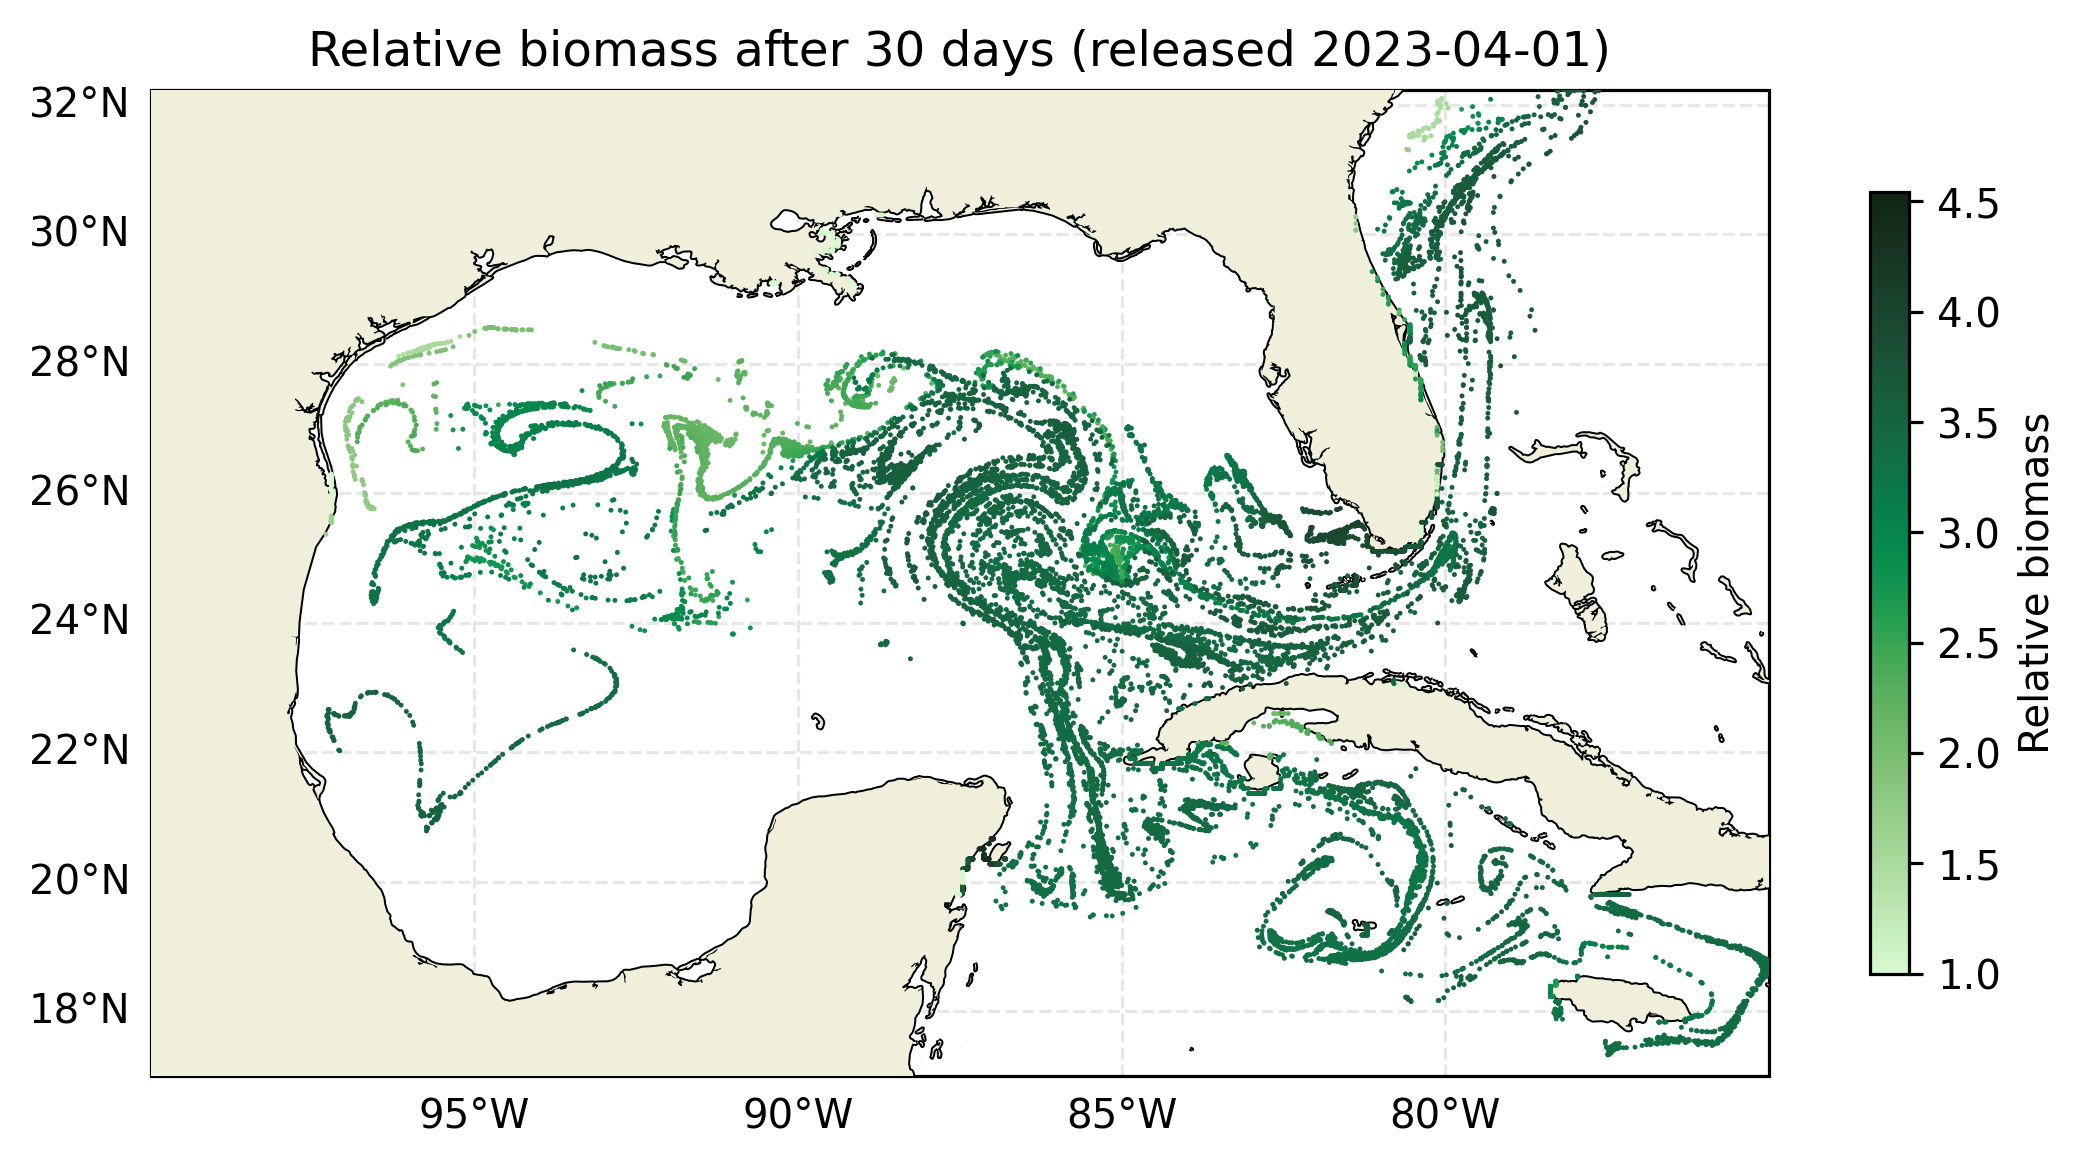

In [25]:
def biomass_plot(DATA, COLORMAP, STARTTIME, FINAL=True):

    colormap = COLORMAP

    #FIGURE
    fig = plt.figure(figsize = (9,7), dpi=290)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

    if FINAL == True:
        cscat = ax.scatter(DATA.lon[:,-1], DATA.lat[:,-1], c = DATA.biomass_SF3[:,-1].values,
        cmap=colormap, s=1.5, linewidth=0, vmin = 1, transform=ccrs.PlateCarree(), zorder=4)
    else:
    #Colored scatter plot with STARTING lon, lat and FINAL values of the categorized weight
        cscat = ax.scatter(DATA.lon[:,0], DATA.lat[:,0], c = DATA.biomass_SF3[:,-1].values,
        cmap=colormap, s=1.1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)

    #Other figure settings
    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'),zorder=3)
    if FINAL == True:
        #satplot = ax.scatter(may_lon, may_lat, s = 0.3, c='b', label='Satellite detections at 01-08-2024',zorder=6)
        ax.set_title(f'Relative biomass after 30 days (released {STARTTIME.date()})')
    else:
        ax.set_title(f'Potential biomass after 30 days, plotted at initial location (released {STARTTIME.date()})')

    ax.set_extent([-100,-75,17,32])
    cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Relative biomass', shrink=0.5)
    return plt.show()

biomass_plot(DSS1, cmo.algae, starttimesim, FINAL=True)

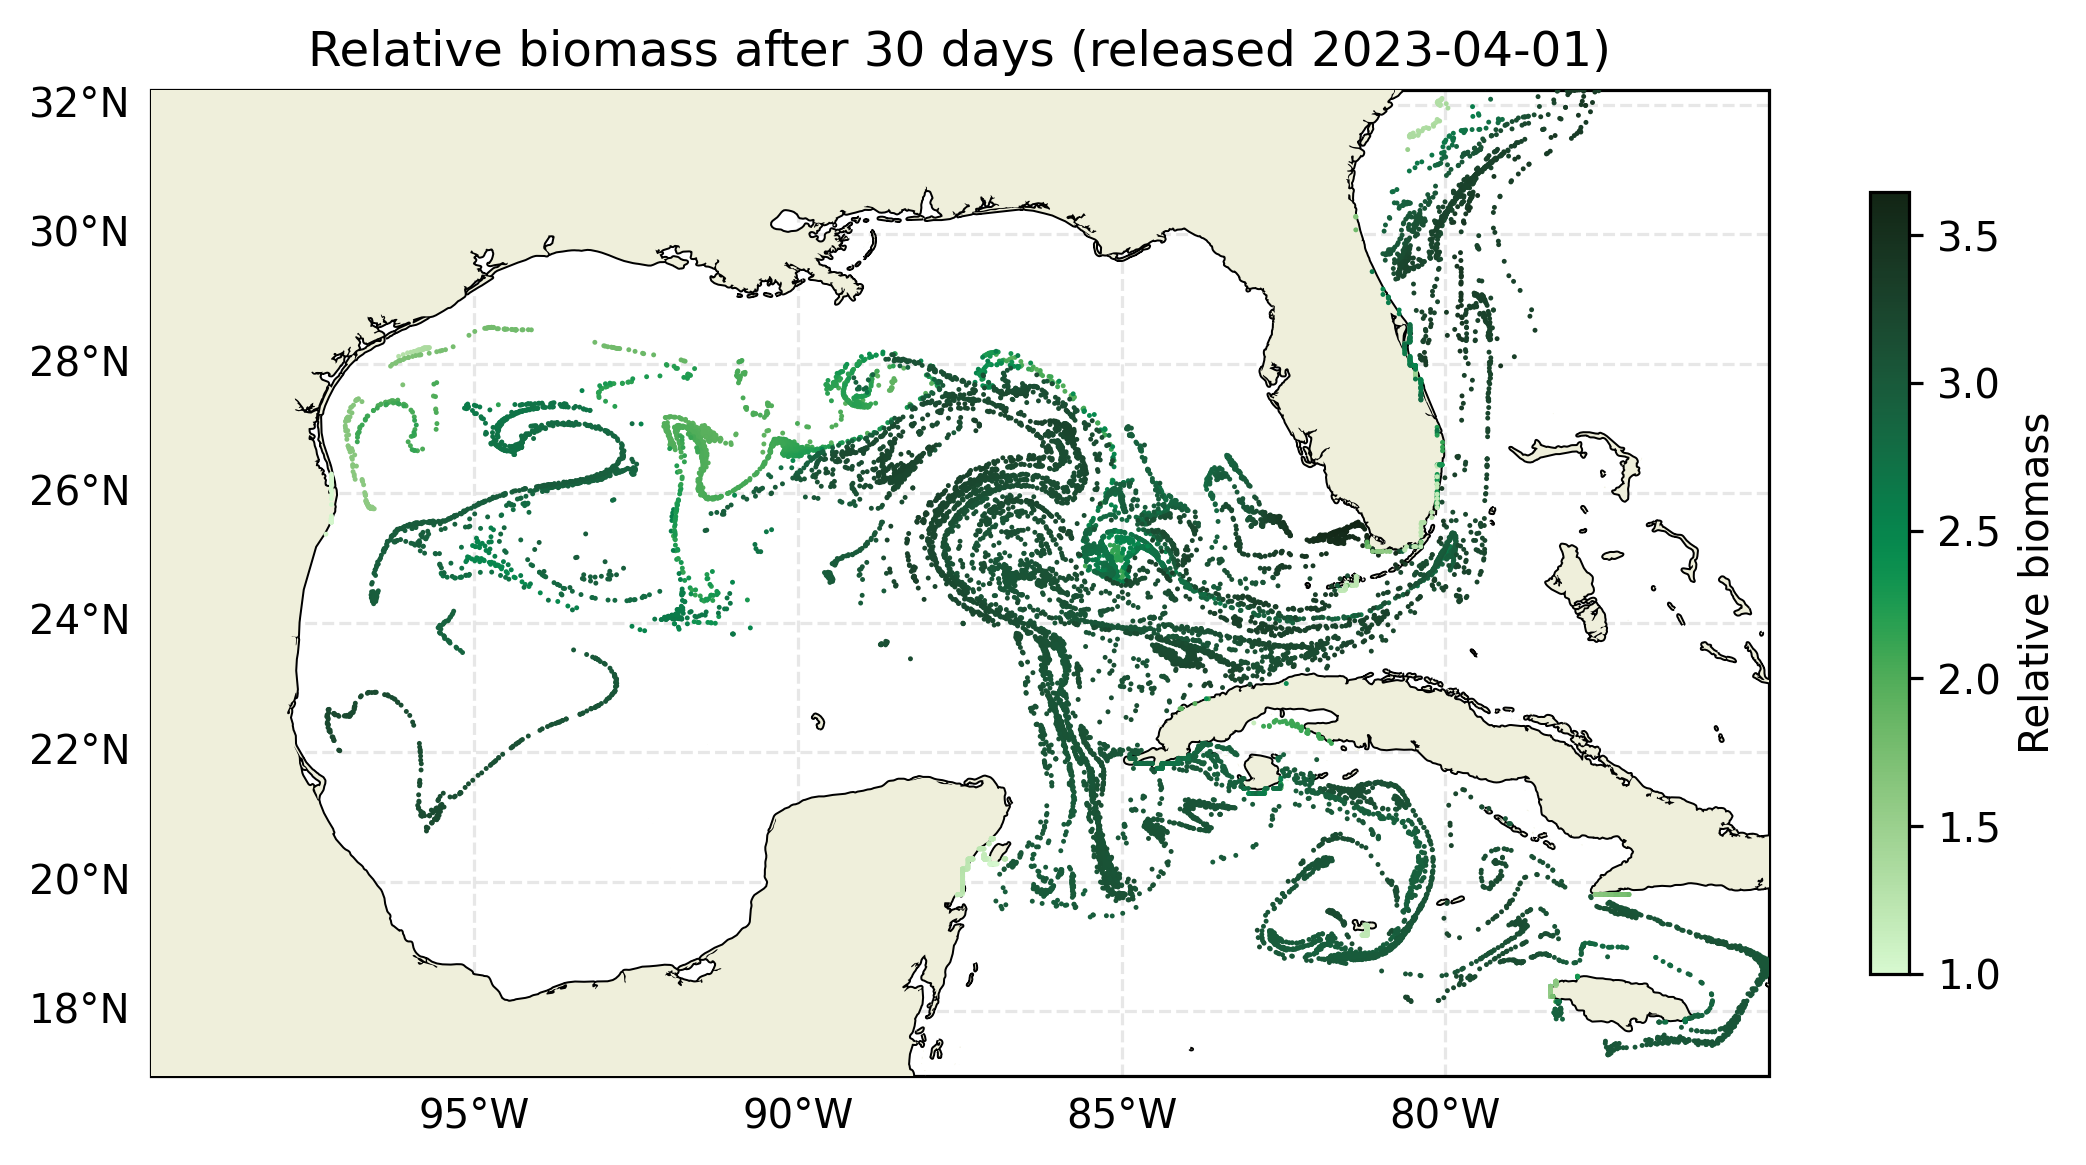

In [26]:
biomass_plot(DSS2, cmo.algae, starttimesim, FINAL=True)

In [48]:
DSSs = [DSS2]
#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSSs] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSSs] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSSs] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSSs]

type(timemean_lim_sal)
print(timemean_lim_sal)

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)

# print(np.shape(timemean_lim_no3))


[<xarray.DataArray 'lim_salinity' (trajectory: 17460)> Size: 70kB
dask.array<mean_agg-aggregate, shape=(17460,), dtype=float32, chunksize=(17460,), chunktype=numpy.ndarray>
Coordinates:
  * trajectory  (trajectory) int64 140kB 0 1 2 3 4 ... 17456 17457 17458 17459]


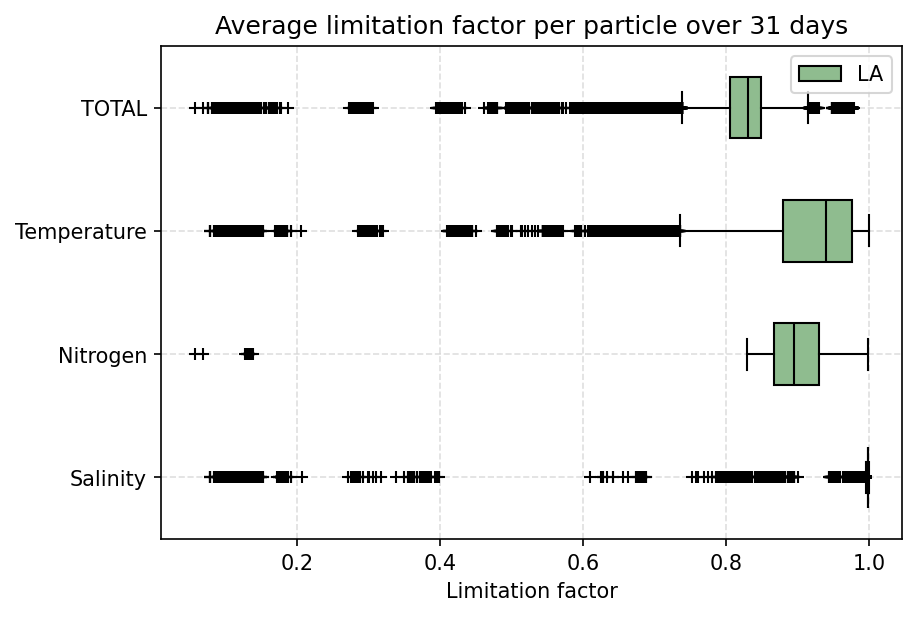

In [49]:
boxplot_list_DSL_lim = [timemean_lim_sal[0,:], timemean_lim_no3[0,:], timemean_lim_temp[0,:], timemean_lim_tot[0,:]] 
limitation_names = ['Salinity', 'Nitrogen', 'Temperature', 'TOTAL']

# X positions for each month
positions_DSE = np.arange(len(limitation_names)) * 1  # spacing between month groups
positions_DSL = positions_DSE          # offset for second box (DSE)

# Create plot
plt.figure(figsize=(6,4), constrained_layout=True, dpi=150)

# Boxplots
plt.boxplot(boxplot_list_DSL_lim, orientation= 'horizontal', positions=positions_DSL, widths=0.5, label='LA', patch_artist=True,
            boxprops=dict(facecolor='darkseagreen'), medianprops=dict(color='black'), sym='+')

# Labels & legend
plt.yticks(positions_DSL , limitation_names, rotation=0)
plt.xlabel('Limitation factor')
#plt.ylabel('Average limitation factor (-)')
plt.title(f'Average limitation factor per particle over 31 days')
plt.legend( loc='upper right')
#plt.ylim(-0.05,1.05)
plt.grid( linestyle='--', alpha=0.4)
plt.show()

In [32]:
#Calculating mean over time of limitation values 
timemean_lim_sal =    [E['lim_salinity'].mean(dim='obs')     for E in DSSs] 
timemean_lim_temp =   [E['lim_temp'].mean(dim='obs')         for E in DSSs] 
timemean_lim_no3 =    [E['lim_no3'].mean(dim='obs')          for E in DSSs] 
timemean_lim_tot =    [E['limitation'].mean(dim='obs')      for E in DSSs]


print(np.shape(timemean_lim_no3))
print(type(timemean_lim_sal))

timemean_lim_sal = np.array(timemean_lim_sal)
timemean_lim_temp = np.array(timemean_lim_temp)
timemean_lim_no3 = np.array(timemean_lim_no3)
timemean_lim_tot = np.array(timemean_lim_tot)

print(type(timemean_lim_sal))

boxplot_list_DSL_lim = [timemean_lim_sal[0,:], timemean_lim_no3[0,:], timemean_lim_temp[0,:], timemean_lim_tot[0,:]] 
#boxplot_list_DSE_lim = [Etimemean_lim_sal[0,:], Etimemean_lim_no3[0,:], Etimemean_lim_temp[0,:], Etimemean_lim_tot[0,:]] 
print(type(boxplot_list_DSL_lim), np.shape(boxplot_list_DSL_lim))
limitation_names = ['Salinity', 'Nitrogen', 'Temperature', 'TOTAL']

# X positions for each month
positions_DSE = np.arange(len(limitation_names)) * 1  # spacing between month groups
positions_DSL = positions_DSE          # offset for second box (DSE)

# Create plot
plt.figure(figsize=(6,4), constrained_layout=True, dpi=150)

# Boxplots for both groups
# plt.boxplot(boxplot_list_DSE_lim, orientation= 'horizontal' ,positions=positions_DSE, widths=0.5, label='EU', patch_artist=True,
#             boxprops=dict(facecolor='peachpuff'), medianprops=dict(color='black'), sym='+')
plt.boxplot(boxplot_list_DSL_lim, orientation= 'horizontal', positions=positions_DSL, widths=0.5, label='LA', patch_artist=True,
            boxprops=dict(facecolor='darkseagreen'), medianprops=dict(color='black'), sym='+')

# Labels & legend
plt.yticks(positions_DSL , limitation_names, rotation=0)
plt.xlabel('Limitation factor')
#plt.ylabel('Average limitation factor (-)')
plt.title(f'Average limitation factor per particle over 31 days. kN = 0.001')
plt.legend( loc='upper right')
#plt.ylim(-0.05,1.05)
plt.grid( linestyle='--', alpha=0.4)
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

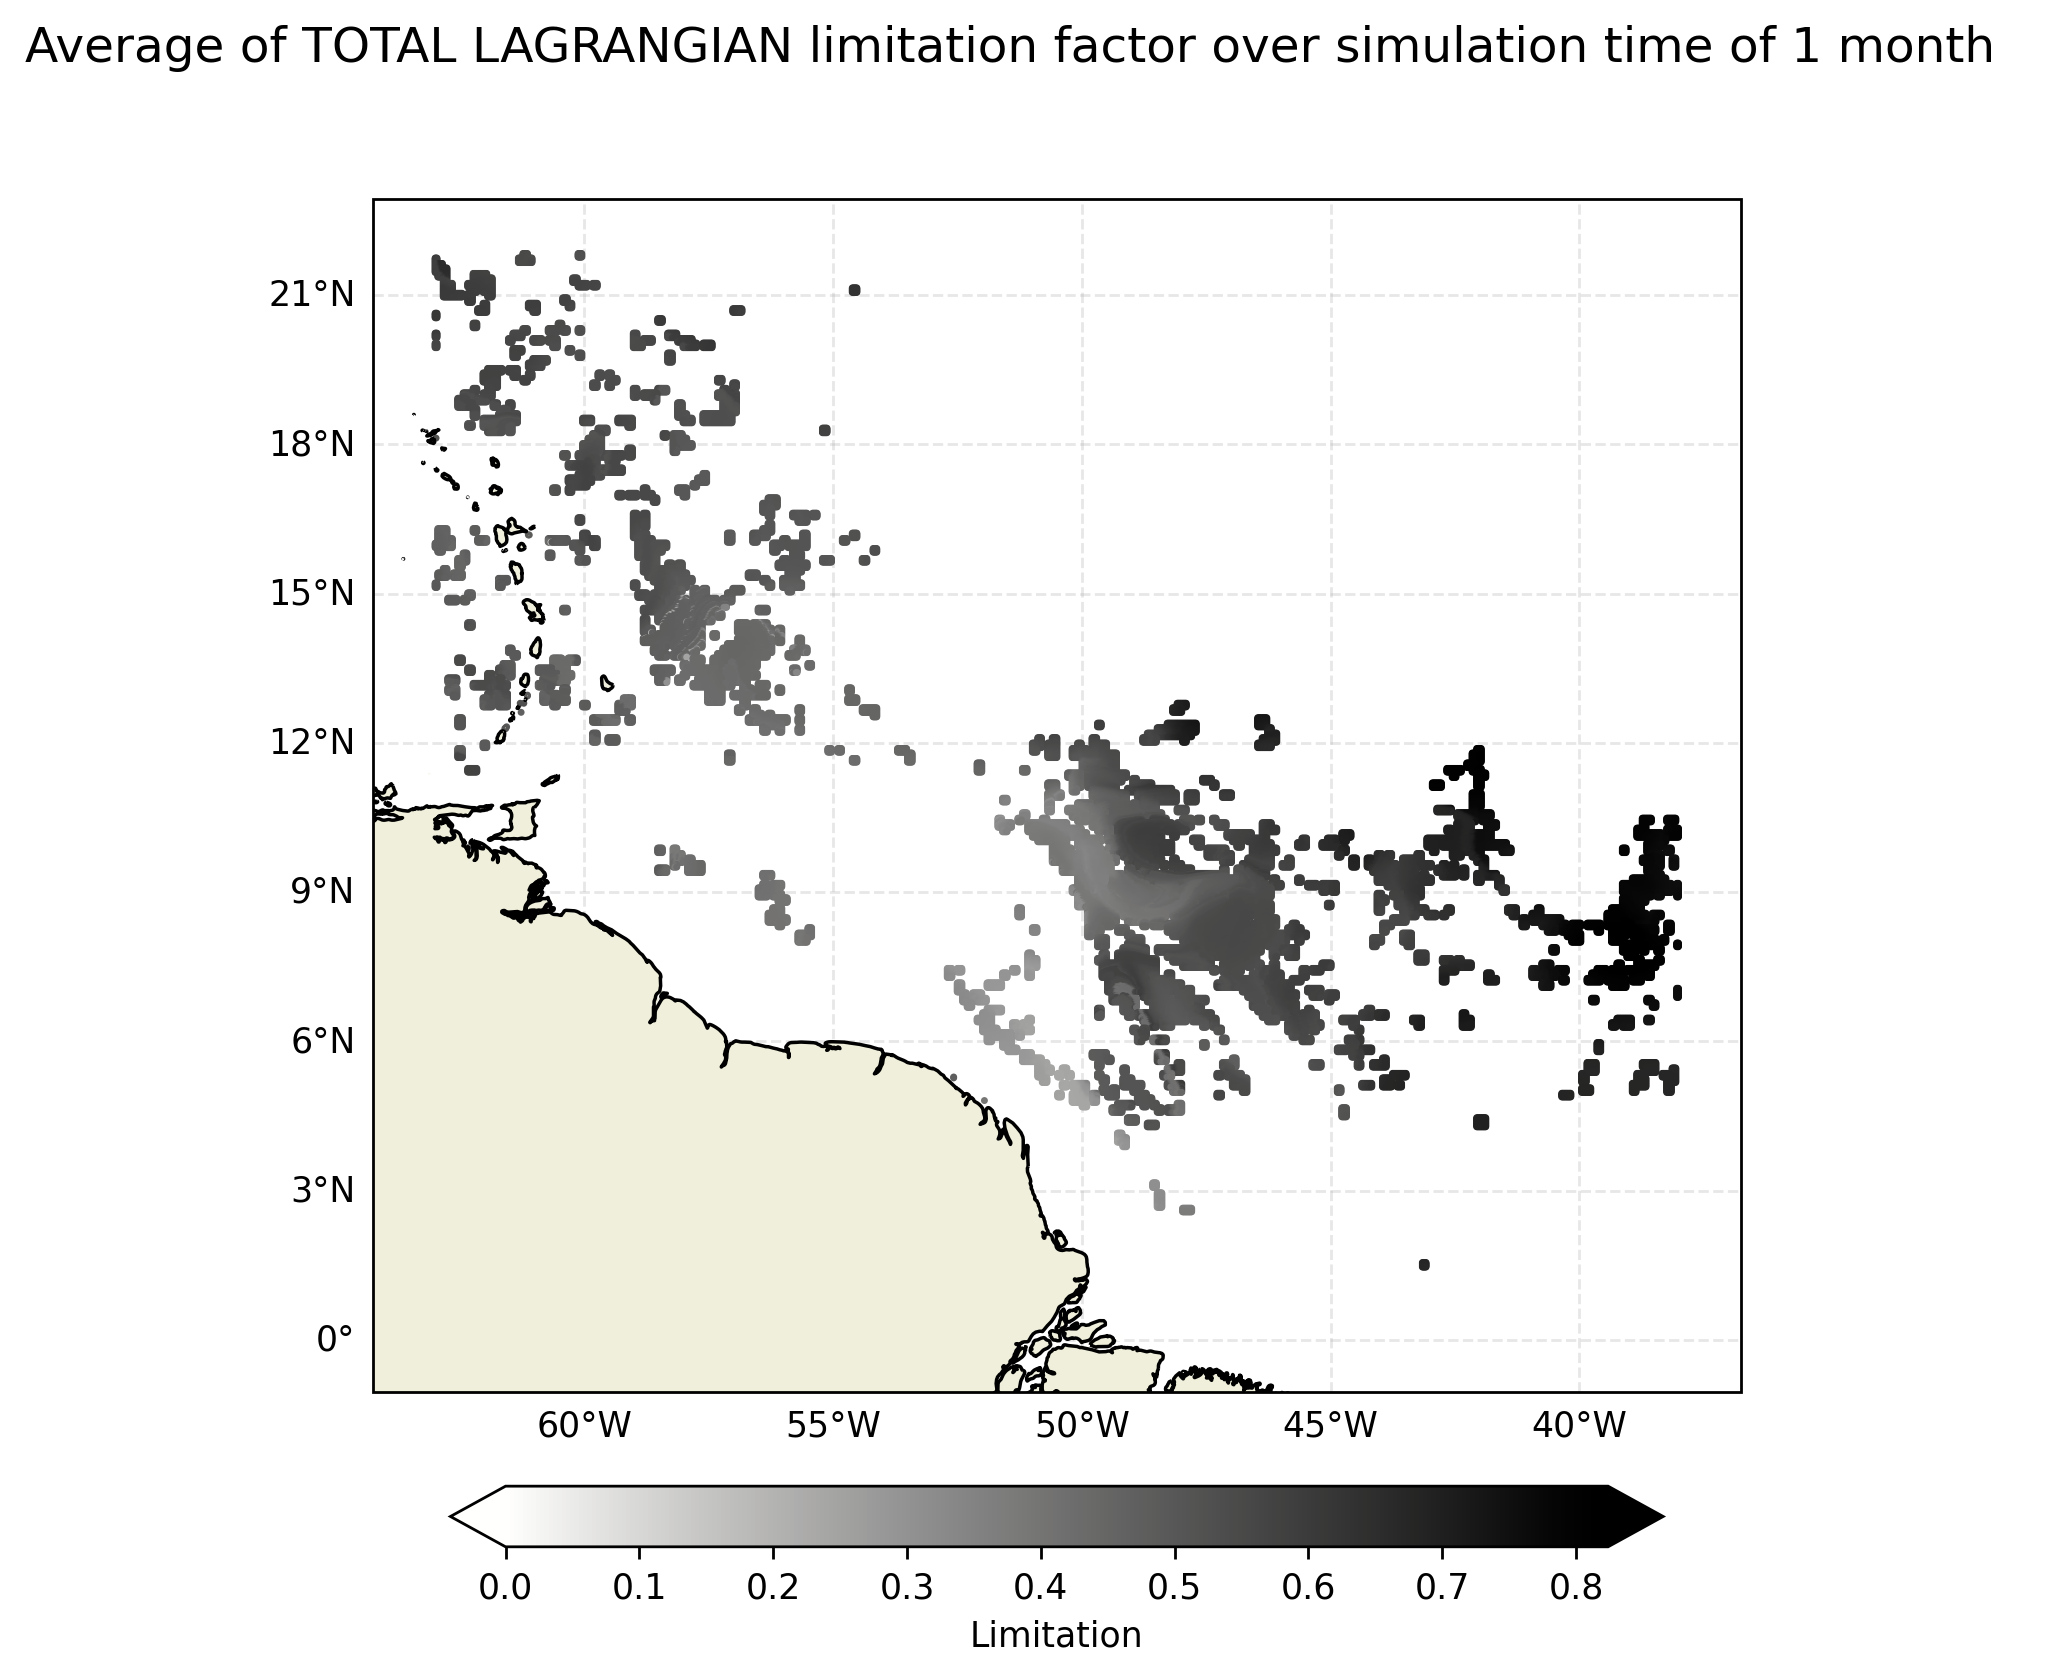

In [101]:
#Looping over each month to estimate the biomass growth difference between Eulerian and Lagrangian simulations
#for i in range(len(DSLs)):
    #sl = DSEs[i].lim_salinity
    #print(biomass_difference.max().values, biomass_difference.min().values )
 
   # DSEs[i]["biomass_difference"] = (DSLs[i].biomass_SF3.dims, biomass_difference.data) #Stores lower boundary of category that particle weight is in in dataset

#FIGURE SETTINGS

#FIGURE
fig = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')
# fig, axes = plt.subplots(1,1,     # 3 rows × 4 columns
#     figsize=(12,6),
#     dpi=240, constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})
# colormap = cmo.gray_r

# #Flattening axes array for loop
# axes = axes.flatten()

# #Plotting for each month
# for i, ax in enumerate(axes):
#     ax.set_extent([-68, -16, -3, 17])
#     ax.gridlines(draw_labels=False, alpha=0.3, linestyle='--', zorder=1)

#Scatter plot for month i
cscat = ax.scatter(
    DSS1.lon[:, 0], #loc
    DSS1.lat[:, 0], #loc
    #c=DSLs[i].biomass_difference[:, -1].values,
    c = timemean_lim_tot[0,:],
    cmap=colormap, s=4, linewidth=0, transform=ccrs.PlateCarree(), zorder=2, 
    #vmin=0.2, vmax=1
    )

#Coastlines, land & subfigure title per month i
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=3)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2)
    #ax.set_title(months[i], fontsize=9)

#Colorbar and title for all months
cbar = fig.colorbar(
    cscat, ax=ax, orientation='horizontal', fraction=0.045, pad=0.07, label='Limitation', extend = 'both')
fig.suptitle('Average of TOTAL LAGRANGIAN limitation factor over simulation time of 1 month  ', fontsize = 14)
plt.show()

In [69]:
def probability_map_12months(DSprobability,  xlim, ylim, title):#FIGURE SETTINGS
    fig, axes = plt.subplots(3,4,     # 3 rows × 4 columns
        figsize=(12,6),
        dpi=240, constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

    #Flattening axes array for loop
    axes = axes.flatten()

    #Plotting for each month
    for i, ax in enumerate(axes):
        ax.set_extent([-72, -14, -5, 19])
        ax.gridlines(draw_labels=False, alpha=0.3, linestyle='--', zorder=1)

        # #Scatter plot for month i
        # cscat = ax.scatter(
        #     DSLs[i].lon[:, -1], #loc
        #     DSLs[i].lat[:, -1], #loc
        #     c=DSLs[i].biomass_SF3[:, -1].values,
        #     cmap=colormap, s=4, linewidth=0, transform=ccrs.PlateCarree(), zorder=2, 
        #     #vmin = 0,  vmax=5 
        #     )

            #create grid
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
        gl.right_labels = False
        gl.top_labels = False

        #plotting probability results 
        DSprobability.plot(ax=ax, cmap=cmo.matter)
        #Coastlines, land & subfigure title per month i
        ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=3)
        ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2)
        ax.set_title(months[i], fontsize=9)

    #Colorbar and title for all months
    cbar = fig.colorbar(
        cscat, ax=axes, orientation='horizontal', fraction=0.045, pad=0.07, label='Relative biomass difference', extend = 'neither')
    fig.suptitle(title, fontsize = 14)
    plt.show()

In [17]:
bins_x = 55
bins_y = 25

not_stranded =  DSS1.where(DSS1['stranded'].compute()==0, drop=True)    #for X in DSLs] 

print(not_stranded.sizes)

print(not_stranded.lon.values)
print(np.isnan(not_stranded.lon.values).sum())  # should be 0 ideally

DSS1_lasttimestep = not_stranded.isel(obs=-1)

probability = c_H.probability_density(not_stranded, bins_x, bins_y)
probability_last = c_H.probability_density(DSS1_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-85, -20]
ylim= [-5, 27]

#plot the results
c_H.probability_map(probability, xlim, ylim, f'Probability density map (released {starttimejul.date()})', None)

Frozen({'trajectory': 103642, 'obs': 372})
[[-61.23572208 -61.24375962 -61.2512423  ... -64.83801887 -64.84964543
  -64.8601639 ]
 [-61.21753365 -61.22549953 -61.23295806 ... -64.72511452 -64.7343626
  -64.74409022]
 [-61.19934522 -61.20725232 -61.2146903  ... -64.67130056 -64.68068624
  -64.68983925]
 ...
 [-28.86959506 -28.81809614 -28.76479464 ... -20.37711247 -20.3542022
  -20.3317601 ]
 [-28.851407   -28.79958202 -28.74600819 ... -20.36618284 -20.34324701
  -20.32079501]
 [-28.83321894 -28.7810716  -28.7272051  ... -20.35794771 -20.33500815
  -20.31257783]]
1727230


ValueError: autodetected range of [nan, nan] is not finite

Total value:  100.0


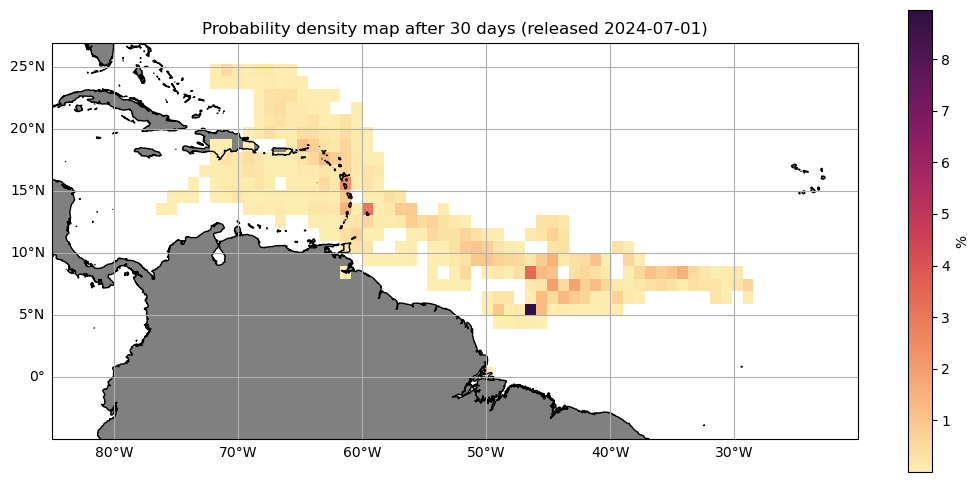

In [68]:
print('Total value: ', np.nansum(probability_last.values))

c_H.probability_map(probability_last, xlim, ylim, f'Probability density map after 30 days (released {starttimejul.date()})', None)

In [20]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation, FFMpegWriter

vmin = DSS2["biomass_SF3"].values.min()
vmax = DSS2["biomass_SF3"].values.max()

fig = plt.figure(figsize = (8,5), constrained_layout=True, dpi = 250)
ax = plt.axes(projection=ccrs.PlateCarree())

ax.gridlines(draw_labels=['left','bottom'], zorder=1, alpha=0.3, linestyle='--')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=3)

#ax.set_extent([-80,-15,-1,26])

#Showing only every 2th output (for speed in creating the animation)
timerange = np.unique(DSS2["time"].values)[::2]

#Indices of the data where time = 0
time_id = np.where(DSS2["time"] == timerange[0])

scat = ax.scatter(
    DSS2.lon.values[time_id],
    DSS2.lat.values[time_id],
    c=DSS2.biomass_SF3.values[time_id].flatten(),
    cmap=cmo.algae,
    s=0.3,
    vmin=vmin, vmax=vmax,
    transform=ccrs.PlateCarree(), zorder=4
)

date_str = np.datetime_as_string(timerange[0], unit='D')
title = ax.set_title(f"Relative biomass of Sargassum particles: {date_str}")

def animate(i):
    date_str = np.datetime_as_string(timerange[i], unit='D')
    title.set_text(f"Relative biomass of Sargassum particles: {date_str}")

    time_id = np.where(DSS2["time"] == timerange[i])
    scat.set_offsets(np.c_[DSS2["lon"].values[time_id], DSS2["lat"].values[time_id]])
    scat.set_array(DSS2["biomass_SF3"].values[time_id].flatten())

cbar = plt.colorbar(scat, ax=ax, orientation='vertical', label='Relative biomass', shrink=0.5)
anim = FuncAnimation(fig, animate, frames=len(timerange), interval=20)

writervideo = FFMpegWriter(fps=20)
anim.save('Anim_westcar_colored3.mp4', writer=writervideo)
plt.close()